In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data

In [3]:
df = pd.read_csv('../data/advertising.csv', header=None)
features=df.iloc[1:,:3].astype(float).to_numpy()
N=features.shape[0]
target=df.iloc[1:,3].astype(float).to_numpy()

# 2. Custom X and y

In [4]:
X=np.hstack((np.ones((N,1)), features))

In [5]:
X.shape

(200, 4)

# 3. Training

In [6]:
def predict(x, theta):
    return x.dot(theta)   

def compute_loss(y_hat, y, m):
    return 1/m * (y_hat-y).T.dot(y_hat-y)

def gradient_compute(x, y_hat, y):
    k=2*(y_hat-y)
    return k.T.dot(x)

def update_theta(theta, gradient, lr):
    return theta - lr*gradient.T

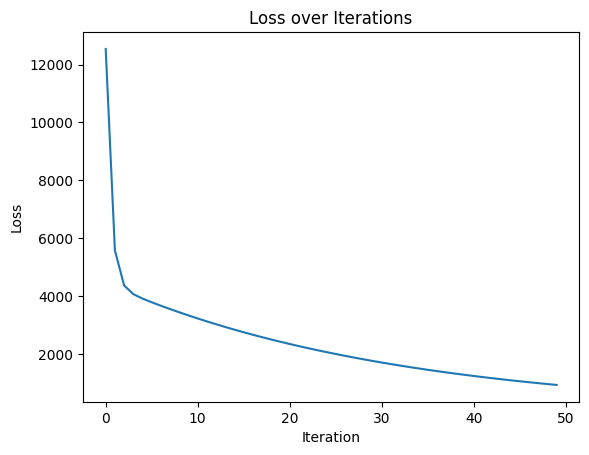

In [7]:
thetas = np.random.randn(4,1)
lr = 0.00001
epoch_max = 50
losses=[]

m=200

for _ in range(epoch_max):
    for i in range(0 ,N, m):
        x=X[i:i+m,:]
        y=np.array(target[i:i+m]).reshape(-1,1)
        y_hat=predict(x, thetas)
        losses.append(compute_loss(y_hat, y, m)[0][0])
        gradient=gradient_compute(x, y_hat, y)/m
        thetas=update_theta(thetas, gradient, lr)

plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss over Iterations')
plt.show()
       